# Topstep ML Pipeline - Interactive Analysis

This notebook provides an interactive way to:
- Explore data and features
- Train models with visualization
- Analyze backtest results
- Experiment with different configurations

**Note:** The pipeline was updated to (1) clean corrupted bars, (2) align labels with next-bar execution, and (3) evaluate via trade-identical backtests. Re-run the notebook top-to-bottom to regenerate plots/metrics.


In [1]:
# Setup
import sys
from pathlib import Path
import os
import json as pyjson
import subprocess

# Add project root to path if not already installed as package
project_root = Path().resolve().parent if Path().resolve().name == 'analysis' else Path().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, JSON

# Project imports (NN pipeline)
from core.simple_config import NN_CONFIG, RISK_CONFIG, TRAINING_CONFIG
from core.selection import bars_per_day
from data.clean_bars import clean_bars
from features.engineer import add_features
from backtesting.backtest import run_backtest_nn
from models.nn_inference import load_nn_bundle, predict_scores_for_bars

# Configure plotting
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')

sns.set_palette('husl')
%matplotlib inline


ModuleNotFoundError: No module named 'torch'

## 1. Load and Explore Data


In [ ]:
# Load data (use provided H5)
# Ensure we're in the project root for relative paths
project_root = Path().resolve().parent if Path().resolve().name == 'analysis' else Path().resolve()
os.chdir(project_root)

data_path = "/mnt/data/es_bars_2010_2025.h5"
if not Path(data_path).exists():
    raise FileNotFoundError(f"Missing data file: {data_path}")

with pd.HDFStore(data_path, "r") as store:
    bars = store["bars_5min"].copy()

bars["timestamp"] = pd.to_datetime(bars["timestamp"], utc=True)
bars = bars.sort_values("timestamp").reset_index(drop=True)
bars = clean_bars(bars, tick_size=RISK_CONFIG.tick_size, verbose=True)
assert bars["timestamp"].is_monotonic_increasing, "Bars must be time-ordered"

print(f"Loaded {len(bars):,} bars")
print(f"Date range: {bars['timestamp'].min()} to {bars['timestamp'].max()}")

# Use a subset for faster iteration if desired
subset_bars = 50000  # set to None for full history
if subset_bars:
    eval_bars = bars.tail(subset_bars).reset_index(drop=True)
else:
    eval_bars = bars.copy()

# Show sample
display(eval_bars.head(10))


Using existing processed data at data/processed/mes_bars.h5

BAR CLEANING REPORT
Input rows:  130,150
Output rows: 130,021  (removed 129)
 - non-finite rows:            0
 - invalid OHLC rows:          0
 - extreme log-return rows:    0
 - extreme range rows:         0
 - outside close quantiles:    129

Loaded 130,021 bars
Date range: 2019-05-06 13:30:00+00:00 to 2025-12-02 20:55:00+00:00


,timestamp,open,high,low,close,volume
0,2019-05-06 13:30:00+00:00,2898.00,2898.50,2894.00,2898.00,1258
1,2019-05-06 13:35:00+00:00,2898.25,2908.50,2898.25,2908.00,6501
2,2019-05-06 13:40:00+00:00,2907.75,2911.25,2906.50,2910.25,3095
3,2019-05-06 13:45:00+00:00,2910.25,2911.50,2909.25,2911.00,2001
4,2019-05-06 13:50:00+00:00,2911.00,2911.00,2905.25,2906.00,2255
5,2019-05-06 13:55:00+00:00,2905.75,2911.75,2905.50,2910.50,2435
6,2019-05-06 14:00:00+00:00,2910.50,2914.50,2910.50,2912.25,2827
7,2019-05-06 14:05:00+00:00,2912.25,2912.25,2909.50,2910.75,3056
8,2019-05-06 14:10:00+00:00,2911.00,2914.00,2911.00,2913.25,4660
9,2019-05-06 14:15:00+00:00,2913.25,2916.50,2913.25,2914.50,3049


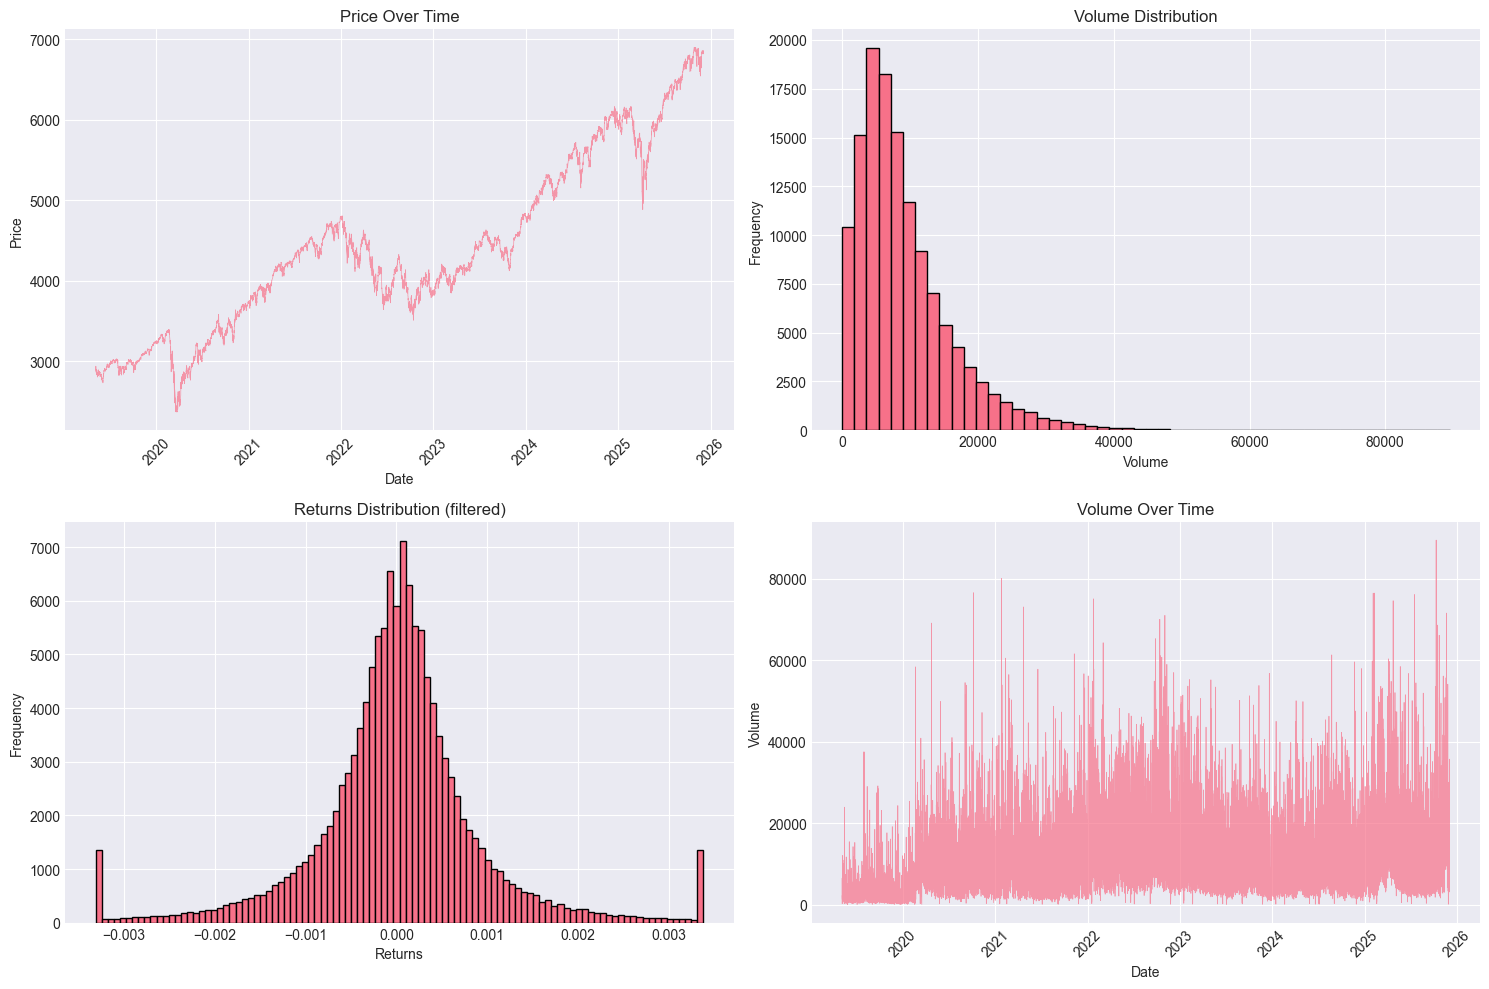

In [ ]:
# Basic statistics and visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price over time
axes[0, 0].plot(bars['timestamp'], bars['close'], alpha=0.7, linewidth=0.5)
axes[0, 0].set_title('Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].tick_params(axis='x', rotation=45)

# Volume distribution
axes[0, 1].hist(bars['volume'], bins=50, edgecolor='black')
axes[0, 1].set_title('Volume Distribution')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].set_ylabel('Frequency')

# Returns distribution (filter out inf and NaN values)
returns = bars['close'].pct_change().dropna()
returns_clean = returns[np.isfinite(returns)]  # Remove inf and NaN
if len(returns_clean) > 0:
    # Clip extreme outliers for better visualization
    q1, q99 = returns_clean.quantile([0.01, 0.99])
    returns_clean = returns_clean.clip(q1, q99)
    axes[1, 0].hist(returns_clean, bins=100, edgecolor='black')
    axes[1, 0].set_title('Returns Distribution (filtered)')
    axes[1, 0].set_xlabel('Returns')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].text(0.5, 0.5, 'No valid returns data', 
                     ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Returns Distribution')

# Volume over time
axes[1, 1].plot(bars['timestamp'], bars['volume'], alpha=0.7, linewidth=0.5)
axes[1, 1].set_title('Volume Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 2. Feature Engineering


In [ ]:
# Add features (use subset for faster exploration)
sample_bars = eval_bars.tail(10000).reset_index(drop=True)  # Last 10k bars
features_df = add_features(sample_bars, verbose=True)

feature_cols = [c for c in features_df.columns if c not in ["timestamp", "open", "high", "low", "close", "volume"]]
print(f"\nFeature columns: {len(feature_cols)}")
display(features_df.describe())



FEATURE ENGINEERING

[1/7] Price features...
[2/7] Trend features...
[3/7] Volatility features...
[4/7] Volume features...
[5/7] Time features...
[6/7] Market structure features...
[7/7] Risk-aware features...

OK: feature engineering complete
  Total features: 52

Feature columns: 52


,open,high,low,close,volume,returns_1,returns_5,returns_12,log_returns_1,body,...,high_50,low_50,range_position_12,range_position_50,dist_from_high_12,dist_from_low_12,estimated_stop_ticks,estimated_risk_usd,trade_affordable,max_contracts_by_risk
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9999.000000,9995.000000,9988.000000,9999.000000,10000.000000,...,9951.000000,9951.000000,9989.000000,9951.000000,9989.000000,9989.000000,9987.000000,9987.000000,10000.000000,10000.000000
mean,6489.580925,6492.502875,6486.519700,6489.583875,10662.017800,0.000015,0.000075,0.000181,0.000015,2.941700,...,6514.048035,6461.686966,0.561444,0.596396,0.001596,0.001999,22.519922,28.149903,0.998700,4.994800
std,267.873498,268.052275,267.706641,267.816577,7802.220831,0.000869,0.001956,0.003034,0.000869,3.268672,...,267.739708,264.470071,0.300047,0.308535,0.002022,0.002192,3.010301,3.762876,0.036034,0.144135
min,5859.000000,5864.000000,5853.000000,5859.250000,89.000000,-0.014577,-0.016868,-0.020682,-0.014684,0.000000,...,5915.500000,5853.000000,0.000000,0.000000,0.000000,0.000000,8.000000,10.000000,0.000000,1.000000
25%,6310.750000,6312.250000,6308.750000,6311.187500,5218.000000,-0.000293,-0.000617,-0.000953,-0.000293,1.000000,...,6335.500000,6288.500000,0.294118,0.316984,0.000405,0.000701,22.928571,28.660714,1.000000,5.000000
50%,6480.250000,6482.500000,6478.500000,6480.250000,8392.000000,0.000037,0.000078,0.000218,0.000037,2.000000,...,6496.250000,6462.750000,0.600000,0.654206,0.000934,0.001352,24.000000,30.000000,1.000000,5.000000
75%,6723.000000,6726.750000,6720.000000,6723.000000,13888.500000,0.000328,0.000773,0.001298,0.000328,3.750000,...,6756.750000,6690.500000,0.834532,0.889340,0.001988,0.002477,24.000000,30.000000,1.000000,5.000000
max,6910.250000,6915.000000,6896.750000,6897.750000,89476.000000,0.017210,0.019220,0.022152,0.017064,58.250000,...,6915.000000,6883.250000,1.000000,1.000000,0.022078,0.022119,24.000000,30.000000,1.000000,5.000000


## 3. Model Training & Backtest


In [ ]:
# Train or load tiny MLP model
model_dir = "models/nn_saved"
fold = 0
force_retrain = False

config_path = Path(model_dir) / f"fold_{fold}" / "config.json"
if force_retrain or not config_path.exists():
    print("Training NN model...")
    subprocess.run(
        [sys.executable, "models/nn_train.py", "--data-path", data_path, "--output-dir", model_dir],
        check=True,
    )
else:
    print(f"Using existing model artifacts at {config_path}")

bundle = load_nn_bundle(model_dir, fold=fold)
nn_cfg = bundle.config.get("nn_config", {})
risk_cfg = bundle.config.get("risk_config", {})

print("NN artifact config:")
display(JSON(nn_cfg, indent=2))


Notebook training config:


<IPython.core.display.JSON object>

Training models (this may take several minutes)...

FEATURE ENGINEERING

[1/7] Price features...
[2/7] Trend features...
[3/7] Volatility features...
[4/7] Volume features...
[5/7] Time features...
[6/7] Market structure features...
[7/7] Risk-aware features...

OK: feature engineering complete
  Total features: 52
Tuned policy (selected on validation via trade-identical backtest):


<IPython.core.display.JSON object>


⚠️  WARNING: Policy tuning disabled both long and short!
The validation window had no profitable configuration.
This means the tuning criteria were too strict.

Overriding with RELAXED POLICY for analysis...

Using relaxed policy instead:


<IPython.core.display.JSON object>


Classification + label-trade stats (train/val/test):


<IPython.core.display.JSON object>


Trade-identical backtest summaries by split (KPI):


<IPython.core.display.JSON object>

In [ ]:
# Run backtest using ML-only selection
from datetime import time as dt_time

session_start = RISK_CONFIG.session_start
session_end = RISK_CONFIG.session_end
if isinstance(risk_cfg.get("session_start"), str):
    session_start = dt_time.fromisoformat(risk_cfg["session_start"])
if isinstance(risk_cfg.get("session_end"), str):
    session_end = dt_time.fromisoformat(risk_cfg["session_end"])

prob_df = predict_scores_for_bars(eval_bars, bundle)

print('Running NN backtest (ML-only)...')
backtest = run_backtest_nn(
    eval_bars,
    prob_df,
    score_threshold=float(nn_cfg["score_threshold"]),
    max_trades_per_day=int(nn_cfg["max_trades_per_day"]),
    min_bars_between_trades=int(nn_cfg["min_bars_between_trades"]),
    enable_long=bool(nn_cfg["enable_long"]),
    enable_short=bool(nn_cfg["enable_short"]),
    horizon_bars=int(nn_cfg["horizon_bars"]),
    execution_mode=str(nn_cfg.get("execution_mode", "time_exit")),
    exit_price_mode=str(nn_cfg.get("exit_price_mode", "bar_close")),
    session_mode=str(nn_cfg.get("session_mode", "RTH")),
    deadline_time=nn_cfg.get("deadline_time"),
    deadline_relax_factor=float(nn_cfg.get("deadline_relax_factor", 0.98)),
    bar_minutes=int(nn_cfg.get("bar_minutes", 5)),
    session_start=session_start,
    session_end=session_end,
    stop_loss_ticks=int(nn_cfg.get("stop_loss_ticks", 24)),
    target_multiplier=float(nn_cfg.get("target_multiplier", 2.0)),
    max_hold_bars=int(nn_cfg.get("max_hold_bars", nn_cfg["horizon_bars"])),
    tick_size=float(nn_cfg.get("tick_size", RISK_CONFIG.tick_size)),
    tick_value=float(nn_cfg.get("tick_value", RISK_CONFIG.tick_value)),
    save_trades_path="analysis/notebook_backtest_trades.csv",
)

scores = prob_df["score"].dropna()
if len(scores) > 0:
    percentiles = {f"p{p}": float(np.nanpercentile(scores, p)) for p in [50, 90, 95, 97, 98, 99, 99.5]}
else:
    percentiles = {}

print("\nScore percentiles:")
print(pyjson.dumps(percentiles, indent=2))
print("\nBacktest summary:")
print(pyjson.dumps(backtest["summary"], indent=2))
print("\nDaily stats:")
print(pyjson.dumps(backtest["daily_stats"], indent=2))

bars_day = bars_per_day(
    session_mode=str(nn_cfg.get("session_mode", "RTH")),
    session_start=session_start,
    session_end=session_end,
    bar_minutes=int(nn_cfg.get("bar_minutes", 5)),
)
print(f"\nBars/day (session): {bars_day} | Target trades/day: {nn_cfg.get('target_trades_per_day')}")


Running backtest (this may take a few minutes)...

✅ BACKTEST vs LIVE ALIGNMENT
Backtest stop: 32 ticks (FIXED)
Live stop:     32 ticks (FIXED)

✅ Fixed stops are now used in both backtest and live trading!
✅ This ensures backtest results accurately predict live performance.

Backtest Summary:


<IPython.core.display.JSON object>

## 4. Monte Carlo Analysis

Monte Carlo simulation bootstraps trade outcomes to assess strategy robustness and potential performance distributions.


In [ ]:
# Import Monte Carlo simulator
from analysis.monte_carlo_simulator import MonteCarloSimulator

# Check if backtest has trades
if "backtest" not in locals() or backtest is None:
    print("⚠️  Backtest results not available. Run the backtest cell first.")
elif "trades" not in backtest:
    print("⚠️  Backtest result missing 'trades' key.")
    print(f"Available keys: {list(backtest.keys())}")
elif not backtest["trades"] or len(backtest["trades"]) == 0:
    num_trades = backtest["summary"].get("trades", 0)
    print(f"⚠️  No trades to analyze in backtest results.")
    print(f"Backtest produced {num_trades} trades.")
    print("\nPossible reasons:")
    print("  • Score threshold too high")
    print("  • Daily top-N budget too strict")
    print("  • Data subset too small")
    print("  • Session mode or spacing too restrictive")
    print("\nTry:")
    print("  • Lowering score_quantile / target_trades_per_day")
    print("  • Expanding subset_bars")
else:
    # Run Monte Carlo simulation on backtest trades
    initial_equity = backtest["summary"]["starting_balance"]
    num_trades = len(backtest["trades"])

    print(f"✅ Found {num_trades} trades for Monte Carlo analysis")
    print(f"Starting equity: ${initial_equity:,.2f}\n")

    simulator = MonteCarloSimulator(backtest["trades"], initial_equity, seed=42)

    print("Running Monte Carlo simulation (500 runs) with BLOCK BOOTSTRAP...")
    print("Block bootstrap preserves temporal structure by sampling blocks of consecutive trades,\n"
          "which is important for time-series data and proper drawdown analysis.\n")

    mc_result = simulator.run(
        runs=500,
        sample_size=None,
        method="block",
        block_size=None,
    )

    print(f"\nBootstrap method: {mc_result.get('method', 'block')}")
    if 'block_size' in mc_result:
        print(f"Block size: {mc_result['block_size']} trades")
        print(f"Number of blocks: {mc_result['n_blocks']}")

    print("\nMonte Carlo Results:")
    display(JSON(mc_result["summary"], indent=2))


✅ Found 1709 trades for Monte Carlo analysis
Starting equity: $50,000.00

Running Monte Carlo simulation (500 runs) with BLOCK BOOTSTRAP...
Block bootstrap preserves temporal structure by sampling blocks of consecutive trades,
which is important for time-series data and proper drawdown analysis.


Bootstrap method: block
Block size: 20 trades
Number of blocks: 1690

Monte Carlo Results:


<IPython.core.display.JSON object>

**Note on Monte Carlo Method:**

The Monte Carlo simulation now uses **block bootstrap** by default, which properly handles time-series data. Unlike simple bootstrap (which randomly samples individual trades), block bootstrap preserves temporal structure by sampling blocks of consecutive trades. This is critical for:

1. **Proper drawdown analysis** - Consecutive losses are preserved
2. **Risk management accuracy** - Daily loss limits and trailing drawdown depend on trade sequence
3. **Realistic equity curves** - Temporal dependencies in trade outcomes are maintained

Block size is automatically calculated as `sqrt(n_trades)` (bounded between 5-20 trades) to optimize the balance between preserving structure and allowing sufficient variability.


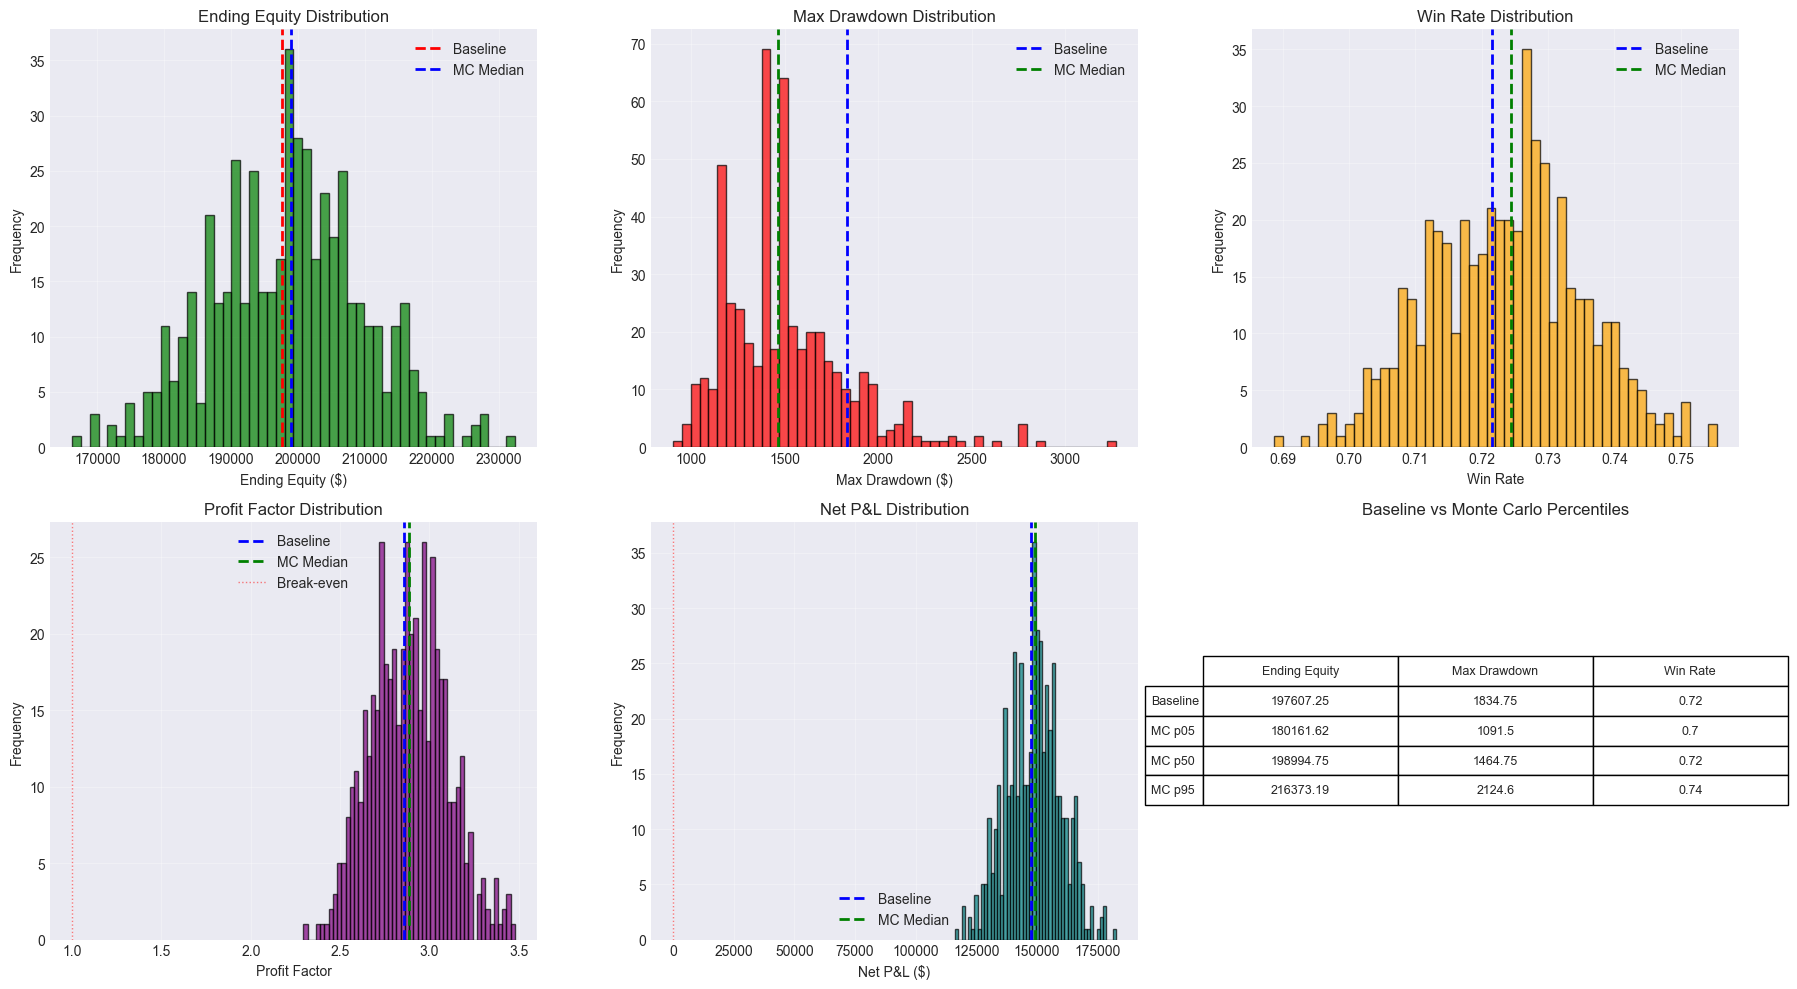


MONTE CARLO INSIGHTS

Ending Equity:
  Baseline: $197607.25
  MC Median (p50): $198994.75
  MC Range (p05-p95): $180161.62 - $216373.19

Max Drawdown:
  Baseline: $1834.75
  MC Median (p50): $1464.75
  MC Range (p05-p95): $1091.50 - $2124.60

Win Rate:
  Baseline: 72.15%
  MC Median (p50): 72.44%
  MC Range (p05-p95): 70.45% - 74.25%

Risk Assessment:
  Worst case (p95) drawdown: $2124.60
  Worst case (p05) ending equity: $180161.62
  ✅ Low risk: Even worst case preserves capital


In [ ]:
# Visualize Monte Carlo distributions
# Check if Monte Carlo results are available and have data
if "mc_result" not in locals() or mc_result is None:
    print("⚠️  Monte Carlo results not available. Run the Monte Carlo simulation cell first.")
elif "raw_results" not in mc_result:
    print("⚠️  No raw results available in Monte Carlo output.")
    print(f"MC result keys: {list(mc_result.keys())}")
    print("This may happen if there were no trades to analyze.")
elif not mc_result["raw_results"].get("ending_equities") or len(mc_result["raw_results"]["ending_equities"]) == 0:
    print("⚠️  No trades to analyze in Monte Carlo results.")
    print("The backtest may have produced zero trades.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Ending equity distribution
    eq_data = mc_result["raw_results"]["ending_equities"]
    axes[0, 0].hist(eq_data, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0, 0].axvline(x=backtest["summary"]["ending_equity"], color='red', linestyle='--', linewidth=2, label='Baseline')
    axes[0, 0].axvline(x=mc_result["summary"]["ending_equity"]["p50"], color='blue', linestyle='--', linewidth=2, label='MC Median')
    axes[0, 0].set_title('Ending Equity Distribution')
    axes[0, 0].set_xlabel('Ending Equity ($)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Max drawdown distribution
    dd_data = mc_result["raw_results"]["max_drawdowns"]
    axes[0, 1].hist(dd_data, bins=50, edgecolor='black', alpha=0.7, color='red')
    axes[0, 1].axvline(x=backtest["summary"]["max_drawdown"], color='blue', linestyle='--', linewidth=2, label='Baseline')
    axes[0, 1].axvline(x=mc_result["summary"]["max_drawdown"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
    axes[0, 1].set_title('Max Drawdown Distribution')
    axes[0, 1].set_xlabel('Max Drawdown ($)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Win rate distribution
    wr_data = mc_result["raw_results"]["win_rates"]
    axes[0, 2].hist(wr_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 2].axvline(x=backtest["summary"]["win_rate"], color='blue', linestyle='--', linewidth=2, label='Baseline')
    axes[0, 2].axvline(x=mc_result["summary"]["win_rate"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
    axes[0, 2].set_title('Win Rate Distribution')
    axes[0, 2].set_xlabel('Win Rate')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Profit factor distribution (filter inf values)
    pf_data = [x for x in mc_result["raw_results"]["profit_factors"] if x < 100]
    axes[1, 0].hist(pf_data, bins=50, edgecolor='black', alpha=0.7, color='purple')
    baseline_pf = backtest["summary"]["profit_factor"]
    if baseline_pf != float('inf'):
        axes[1, 0].axvline(x=baseline_pf, color='blue', linestyle='--', linewidth=2, label='Baseline')
    axes[1, 0].axvline(x=mc_result["summary"]["profit_factor"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
    axes[1, 0].axvline(x=1.0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Break-even')
    axes[1, 0].set_title('Profit Factor Distribution')
    axes[1, 0].set_xlabel('Profit Factor')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Net P&L distribution
    pnl_data = mc_result["raw_results"]["net_pnls"]
    axes[1, 1].hist(pnl_data, bins=50, edgecolor='black', alpha=0.7, color='teal')
    axes[1, 1].axvline(x=backtest["summary"]["net_pnl"], color='blue', linestyle='--', linewidth=2, label='Baseline')
    axes[1, 1].axvline(x=mc_result["summary"]["net_pnl"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
    axes[1, 1].axvline(x=0, color='red', linestyle=':', linewidth=1, alpha=0.5)
    axes[1, 1].set_title('Net P&L Distribution')
    axes[1, 1].set_xlabel('Net P&L ($)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Summary comparison
    summary_metrics = {
        'Ending Equity': {
            'Baseline': backtest["summary"]["ending_equity"],
            'MC p05': mc_result["summary"]["ending_equity"]["p05"],
            'MC p50': mc_result["summary"]["ending_equity"]["p50"],
            'MC p95': mc_result["summary"]["ending_equity"]["p95"],
        },
        'Max Drawdown': {
            'Baseline': backtest["summary"]["max_drawdown"],
            'MC p05': mc_result["summary"]["max_drawdown"]["p05"],
            'MC p50': mc_result["summary"]["max_drawdown"]["p50"],
            'MC p95': mc_result["summary"]["max_drawdown"]["p95"],
        },
        'Win Rate': {
            'Baseline': backtest["summary"]["win_rate"],
            'MC p05': mc_result["summary"]["win_rate"]["p05"],
            'MC p50': mc_result["summary"]["win_rate"]["p50"],
            'MC p95': mc_result["summary"]["win_rate"]["p95"],
        },
    }

    summary_df = pd.DataFrame(summary_metrics)
    axes[1, 2].axis('tight')
    axes[1, 2].axis('off')
    table = axes[1, 2].table(cellText=summary_df.values.round(2), 
                             rowLabels=summary_df.index,
                             colLabels=summary_df.columns,
                             cellLoc='center',
                             loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    axes[1, 2].set_title('Baseline vs Monte Carlo Percentiles')

    plt.tight_layout()
    plt.show()

    # Print key insights
    print("\n" + "="*60)
    print("MONTE CARLO INSIGHTS")
    print("="*60)
    print(f"\nEnding Equity:")
    print(f"  Baseline: ${backtest['summary']['ending_equity']:.2f}")
    print(f"  MC Median (p50): ${mc_result['summary']['ending_equity']['p50']:.2f}")
    print(f"  MC Range (p05-p95): ${mc_result['summary']['ending_equity']['p05']:.2f} - ${mc_result['summary']['ending_equity']['p95']:.2f}")

    print(f"\nMax Drawdown:")
    print(f"  Baseline: ${backtest['summary']['max_drawdown']:.2f}")
    print(f"  MC Median (p50): ${mc_result['summary']['max_drawdown']['p50']:.2f}")
    print(f"  MC Range (p05-p95): ${mc_result['summary']['max_drawdown']['p05']:.2f} - ${mc_result['summary']['max_drawdown']['p95']:.2f}")

    print(f"\nWin Rate:")
    print(f"  Baseline: {backtest['summary']['win_rate']:.2%}")
    print(f"  MC Median (p50): {mc_result['summary']['win_rate']['p50']:.2%}")
    print(f"  MC Range (p05-p95): {mc_result['summary']['win_rate']['p05']:.2%} - {mc_result['summary']['win_rate']['p95']:.2%}")

    # Risk assessment
    p95_dd = mc_result['summary']['max_drawdown']['p95']
    p05_equity = mc_result['summary']['ending_equity']['p05']
    print(f"\nRisk Assessment:")
    print(f"  Worst case (p95) drawdown: ${p95_dd:.2f}")
    print(f"  Worst case (p05) ending equity: ${p05_equity:.2f}")
    if p05_equity < initial_equity * 0.8:
        print(f"  ⚠️  High risk: 5% chance of losing >20% of capital")
    elif p05_equity < initial_equity:
        print(f"  ⚠️  Moderate risk: 5% chance of ending below starting equity")
    else:
        print(f"  ✅ Low risk: Even worst case preserves capital")

## 5. Performance Analysis & Improvement Ideas

Analyze trade characteristics to identify improvement opportunities.


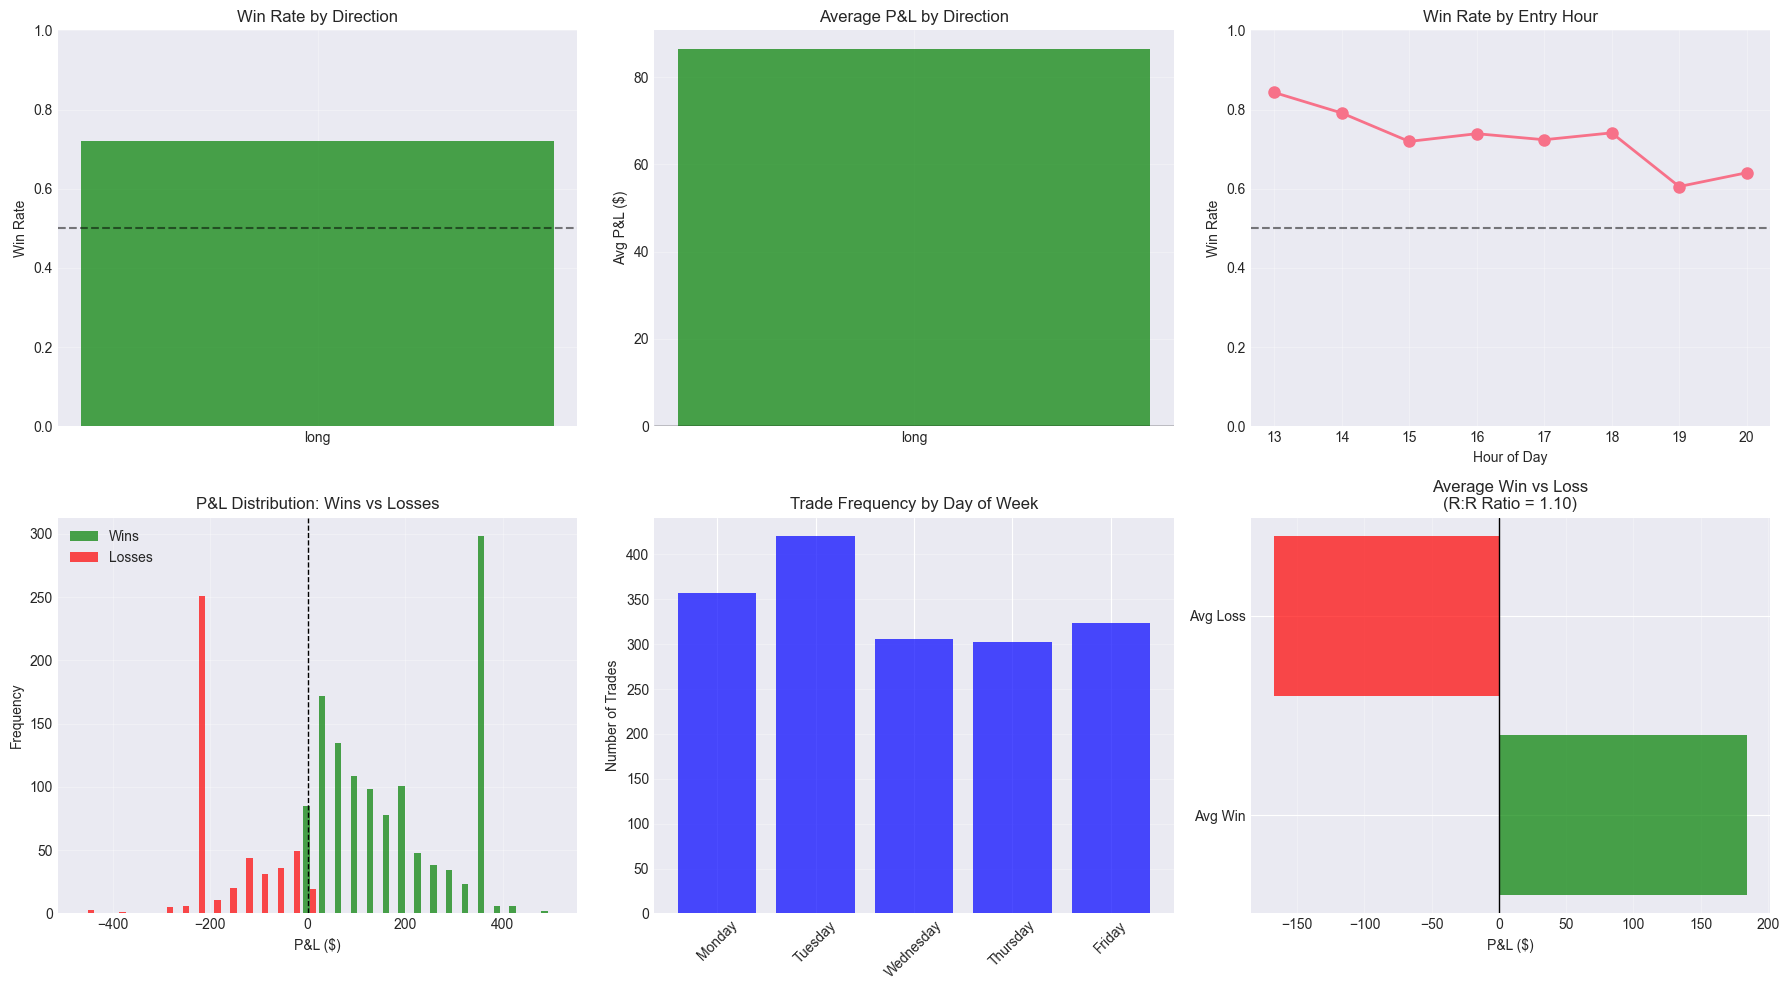


PERFORMANCE ANALYSIS & IMPROVEMENT SUGGESTIONS

1. Risk/Reward Analysis:
   Average Win: $184.25
   Average Loss: $167.17
   Risk:Reward Ratio: 1.10
   💡 R:R < 1.5: Could improve by increasing target size or reducing stop size

2. Direction Performance:
   LONG: Win Rate=72.15%, Avg P&L=$86.37

3. Time-based Patterns:
   Best hour: 13:00 (WR=84.33%)
   Worst hour: 19:00 (WR=60.56%)

4. Trade Frequency:
   Total trades: 1709
   Most active day: Tuesday (420 trades)

5. Consistency:
   Win rate std dev across hours: 0.076
      ✅ Relatively consistent performance across time periods


In [ ]:
# Detailed trade analysis
trades_df = pd.DataFrame(backtest["trades"])

if len(trades_df) > 0:
    # Add derived metrics
    trades_df["is_win"] = trades_df["pnl"] > 0
    trades_df["is_loss"] = trades_df["pnl"] < 0
    trades_df["abs_pnl"] = trades_df["pnl"].abs()
    
    # Time analysis
    trades_df["entry_time"] = pd.to_datetime(trades_df["entry_time"])
    trades_df["exit_time"] = pd.to_datetime(trades_df["exit_time"])
    trades_df["hold_time"] = trades_df["exit_time"] - trades_df["entry_time"]
    trades_df["entry_hour"] = trades_df["entry_time"].dt.hour
    trades_df["entry_day"] = trades_df["entry_time"].dt.day_name()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Win rate by direction
    wr_by_dir = trades_df.groupby("direction")["is_win"].mean()
    axes[0, 0].bar(wr_by_dir.index, wr_by_dir.values, color=['green', 'red'], alpha=0.7)
    axes[0, 0].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_title('Win Rate by Direction')
    axes[0, 0].set_ylabel('Win Rate')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Average P&L by direction
    avg_pnl_by_dir = trades_df.groupby("direction")["pnl"].mean()
    colors = ['green' if x > 0 else 'red' for x in avg_pnl_by_dir.values]
    axes[0, 1].bar(avg_pnl_by_dir.index, avg_pnl_by_dir.values, color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].set_title('Average P&L by Direction')
    axes[0, 1].set_ylabel('Avg P&L ($)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Win rate by entry hour
    wr_by_hour = trades_df.groupby("entry_hour")["is_win"].mean()
    axes[0, 2].plot(wr_by_hour.index, wr_by_hour.values, marker='o', linewidth=2, markersize=8)
    axes[0, 2].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
    axes[0, 2].set_title('Win Rate by Entry Hour')
    axes[0, 2].set_xlabel('Hour of Day')
    axes[0, 2].set_ylabel('Win Rate')
    axes[0, 2].set_ylim(0, 1)
    axes[0, 2].grid(True, alpha=0.3)
    
    # P&L distribution by win/loss
    wins = trades_df[trades_df["is_win"]]["pnl"]
    losses = trades_df[trades_df["is_loss"]]["pnl"]
    axes[1, 0].hist([wins, losses], bins=30, label=['Wins', 'Losses'], alpha=0.7, color=['green', 'red'])
    axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('P&L Distribution: Wins vs Losses')
    axes[1, 0].set_xlabel('P&L ($)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Trade frequency by day of week
    trades_by_day = trades_df["entry_day"].value_counts()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    trades_by_day = trades_by_day.reindex([d for d in day_order if d in trades_by_day.index])
    axes[1, 1].bar(range(len(trades_by_day)), trades_by_day.values, alpha=0.7, color='blue')
    axes[1, 1].set_xticks(range(len(trades_by_day)))
    axes[1, 1].set_xticklabels(trades_by_day.index, rotation=45)
    axes[1, 1].set_title('Trade Frequency by Day of Week')
    axes[1, 1].set_ylabel('Number of Trades')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Risk/Reward analysis
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = abs(losses.mean()) if len(losses) > 0 else 1
    rr_ratio = avg_win / avg_loss if avg_loss > 0 else 0
    
    axes[1, 2].barh(['Avg Win', 'Avg Loss'], [avg_win, -avg_loss], color=['green', 'red'], alpha=0.7)
    axes[1, 2].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 2].set_title(f'Average Win vs Loss\n(R:R Ratio = {rr_ratio:.2f})')
    axes[1, 2].set_xlabel('P&L ($)')
    axes[1, 2].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print improvement suggestions
    print("\n" + "="*60)
    print("PERFORMANCE ANALYSIS & IMPROVEMENT SUGGESTIONS")
    print("="*60)
    
    print(f"\n1. Risk/Reward Analysis:")
    print(f"   Average Win: ${avg_win:.2f}")
    print(f"   Average Loss: ${avg_loss:.2f}")
    print(f"   Risk:Reward Ratio: {rr_ratio:.2f}")
    if rr_ratio < 1.0:
        print(f"   ⚠️  R:R < 1.0: Average loss exceeds average win - consider tighter stops or wider targets")
    elif rr_ratio < 1.5:
        print(f"   💡 R:R < 1.5: Could improve by increasing target size or reducing stop size")
    else:
        print(f"   ✅ Good R:R ratio")
    
    print(f"\n2. Direction Performance:")
    for direction in trades_df["direction"].unique():
        dir_trades = trades_df[trades_df["direction"] == direction]
        dir_wr = dir_trades["is_win"].mean()
        dir_avg_pnl = dir_trades["pnl"].mean()
        print(f"   {direction.upper()}: Win Rate={dir_wr:.2%}, Avg P&L=${dir_avg_pnl:.2f}")
        if dir_wr < 0.45:
            print(f"      ⚠️  Low win rate for {direction} - consider filtering or adjusting entry criteria")
    
    print(f"\n3. Time-based Patterns:")
    best_hour = wr_by_hour.idxmax()
    worst_hour = wr_by_hour.idxmin()
    print(f"   Best hour: {best_hour}:00 (WR={wr_by_hour[best_hour]:.2%})")
    print(f"   Worst hour: {worst_hour}:00 (WR={wr_by_hour[worst_hour]:.2%})")
    if wr_by_hour[worst_hour] < 0.4:
        print(f"      💡 Consider avoiding trades during {worst_hour}:00")
    
    print(f"\n4. Trade Frequency:")
    print(f"   Total trades: {len(trades_df)}")
    print(f"   Most active day: {trades_by_day.idxmax()} ({trades_by_day.max()} trades)")
    
    # Check for consistency
    wr_std = wr_by_hour.std() if len(wr_by_hour) > 1 else 0
    print(f"\n5. Consistency:")
    print(f"   Win rate std dev across hours: {wr_std:.3f}")
    if wr_std > 0.15:
        print(f"      ⚠️  High variance - strategy performance varies significantly by time")
    else:
        print(f"      ✅ Relatively consistent performance across time periods")



## 6. 3D Visualizations

Multi-dimensional analysis of strategy performance.


/var/folders/2n/wfddn5mn0d18dcql5s1h9lhm0000gn/T/ipykernel_37129/2350844859.py:164: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


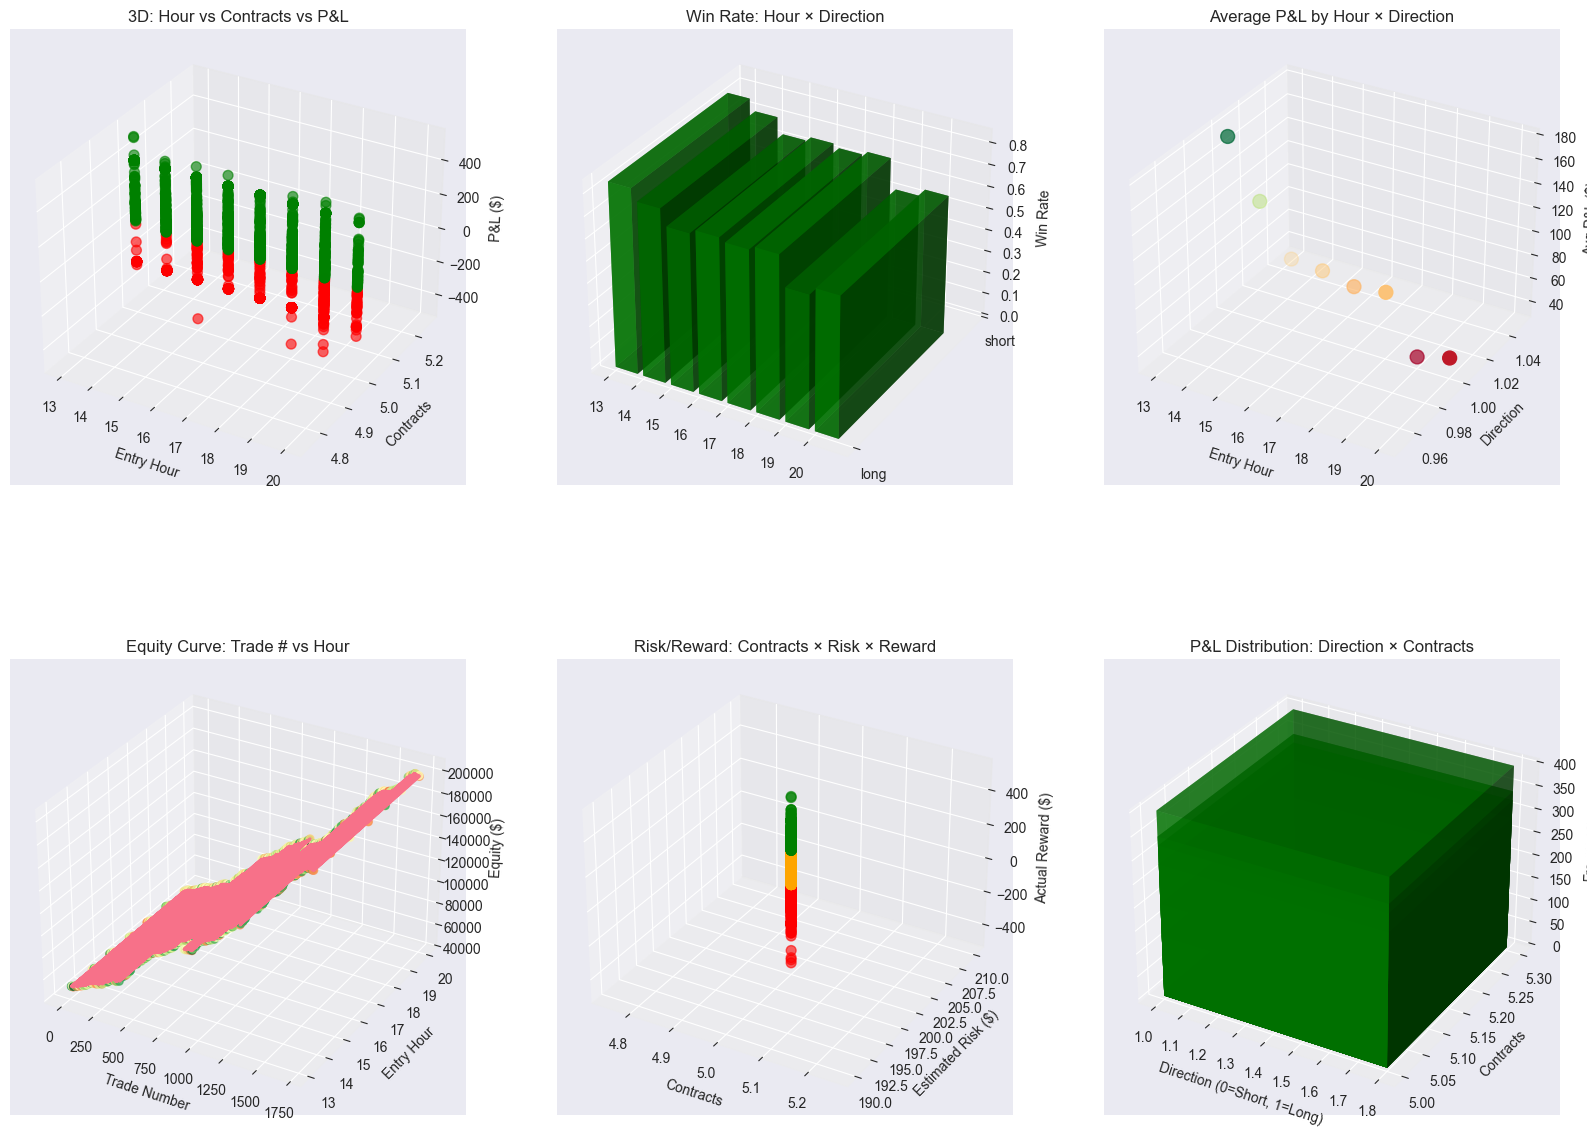

3D visualizations complete!


In [ ]:
# 3D Visualizations
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

if len(trades_df) > 0:
    fig = plt.figure(figsize=(20, 15))
    
    # 1. 3D Scatter: Entry Time vs P&L vs Contracts
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    colors = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
    scatter = ax1.scatter(
        trades_df['entry_hour'], 
        trades_df['contracts'], 
        trades_df['pnl'],
        c=colors, 
        alpha=0.6,
        s=50
    )
    ax1.set_xlabel('Entry Hour')
    ax1.set_ylabel('Contracts')
    ax1.set_zlabel('P&L ($)')
    ax1.set_title('3D: Hour vs Contracts vs P&L')
    
    # 2. 3D Bar Chart: Win Rate by Direction and Hour
    ax2 = fig.add_subplot(2, 3, 2, projection='3d')
    hours = sorted(trades_df['entry_hour'].unique())
    directions = ['long', 'short']
    xpos = []
    ypos = []
    zpos = []
    dx = []
    dy = []
    dz = []
    colors_bar = []
    
    for i, hour in enumerate(hours):
        for j, direction in enumerate(directions):
            mask = (trades_df['entry_hour'] == hour) & (trades_df['direction'] == direction)
            if mask.sum() > 0:
                wr = trades_df[mask]['is_win'].mean()
                xpos.append(i)
                ypos.append(j)
                zpos.append(0)
                dx.append(0.8)
                dy.append(0.8)
                dz.append(wr)
                colors_bar.append('green' if wr > 0.5 else 'red')
    
    if xpos:
        ax2.bar3d(xpos, ypos, zpos, dx, dy, dz, alpha=0.7, color=colors_bar)
        ax2.set_xticks(range(len(hours)))
        ax2.set_xticklabels(hours)
        ax2.set_yticks(range(len(directions)))
        ax2.set_yticklabels(directions)
        ax2.set_zlabel('Win Rate')
        ax2.set_title('Win Rate: Hour × Direction')
    
    # 3. 3D Surface: Performance Heatmap (if we have enough data points)
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    if len(hours) > 2:
        hour_grid = []
        direction_grid = []
        pnl_grid = []
        
        for hour in hours:
            for direction in directions:
                mask = (trades_df['entry_hour'] == hour) & (trades_df['direction'] == direction)
                if mask.sum() > 0:
                    avg_pnl = trades_df[mask]['pnl'].mean()
                    hour_grid.append(hour)
                    direction_grid.append(1 if direction == 'long' else 0)
                    pnl_grid.append(avg_pnl)
        
        if len(hour_grid) > 4:
            # Create surface plot
            from scipy.interpolate import griddata
            import numpy as np
            
            xi = np.linspace(min(hour_grid), max(hour_grid), 20)
            yi = np.linspace(0, 1, 10)
            xi, yi = np.meshgrid(xi, yi)
            
            try:
                zi = griddata((hour_grid, direction_grid), pnl_grid, (xi, yi), method='cubic')
                surf = ax3.plot_surface(xi, yi, zi, cmap='RdYlGn', alpha=0.8, linewidth=0)
                ax3.set_xlabel('Entry Hour')
                ax3.set_ylabel('Direction (0=Short, 1=Long)')
                ax3.set_zlabel('Avg P&L ($)')
                ax3.set_title('Average P&L Surface')
                fig.colorbar(surf, ax=ax3, shrink=0.5)
            except:
                # Fallback to scatter if interpolation fails
                ax3.scatter(hour_grid, direction_grid, pnl_grid, c=pnl_grid, cmap='RdYlGn', s=100)
                ax3.set_xlabel('Entry Hour')
                ax3.set_ylabel('Direction')
                ax3.set_zlabel('Avg P&L ($)')
                ax3.set_title('Average P&L by Hour × Direction')
    
    # 4. 3D Line: Equity Curve Evolution
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')
    if 'cumulative_pnl' not in trades_df.columns:
        trades_df['cumulative_pnl'] = trades_df['pnl'].cumsum()
    if 'trade_num' not in trades_df.columns:
        trades_df['trade_num'] = range(len(trades_df))
    
    equity_curve_3d = initial_equity + trades_df['cumulative_pnl'].values
    ax4.plot(trades_df['trade_num'], trades_df['entry_hour'], equity_curve_3d, linewidth=2)
    ax4.scatter(trades_df['trade_num'], trades_df['entry_hour'], equity_curve_3d, 
                c=trades_df['pnl'], cmap='RdYlGn', s=30, alpha=0.7)
    ax4.set_xlabel('Trade Number')
    ax4.set_ylabel('Entry Hour')
    ax4.set_zlabel('Equity ($)')
    ax4.set_title('Equity Curve: Trade # vs Hour')
    
    # 5. 3D Scatter: Risk/Reward Analysis
    ax5 = fig.add_subplot(2, 3, 5, projection='3d')
    # Calculate risk (stop distance) and reward (actual P&L)
    trades_df['risk_estimate'] = trades_df['stop_ticks'] * 1.25 * trades_df['contracts']  # Estimated risk
    trades_df['reward'] = trades_df['pnl']
    trades_df['rr_ratio'] = trades_df['reward'] / trades_df['risk_estimate'].abs().replace(0, 1)
    
    scatter_colors = ['green' if x > 1 else 'orange' if x > 0 else 'red' for x in trades_df['rr_ratio']]
    ax5.scatter(
        trades_df['contracts'],
        trades_df['risk_estimate'],
        trades_df['reward'],
        c=scatter_colors,
        alpha=0.6,
        s=50
    )
    ax5.set_xlabel('Contracts')
    ax5.set_ylabel('Estimated Risk ($)')
    ax5.set_zlabel('Actual Reward ($)')
    ax5.set_title('Risk/Reward: Contracts × Risk × Reward')
    
    # 6. 3D Histogram: P&L Distribution by Direction and Contracts
    ax6 = fig.add_subplot(2, 3, 6, projection='3d')
    
    # Create bins
    pnl_bins = np.linspace(trades_df['pnl'].min(), trades_df['pnl'].max(), 10)
    contract_bins = sorted(trades_df['contracts'].unique())
    
    for direction in directions:
        dir_trades = trades_df[trades_df['direction'] == direction]
        for contracts in contract_bins:
            contract_trades = dir_trades[dir_trades['contracts'] == contracts]
            if len(contract_trades) > 0:
                hist, _ = np.histogram(contract_trades['pnl'], bins=pnl_bins)
                xpos = np.array([direction == 'long'] * len(hist))
                ypos = np.array([contracts] * len(hist))
                zpos = np.zeros(len(hist))
                dx = 0.8 * np.ones(len(hist))
                dy = 0.3 * np.ones(len(hist))
                dz = hist.astype(float)
                
                color = 'green' if direction == 'long' else 'blue'
                ax6.bar3d(xpos, ypos, zpos, dx, dy, dz, alpha=0.6, color=color)
    
    ax6.set_xlabel('Direction (0=Short, 1=Long)')
    ax6.set_ylabel('Contracts')
    ax6.set_zlabel('Frequency')
    ax6.set_title('P&L Distribution: Direction × Contracts')
    
    plt.tight_layout()
    plt.show()
    
    print("3D visualizations complete!")


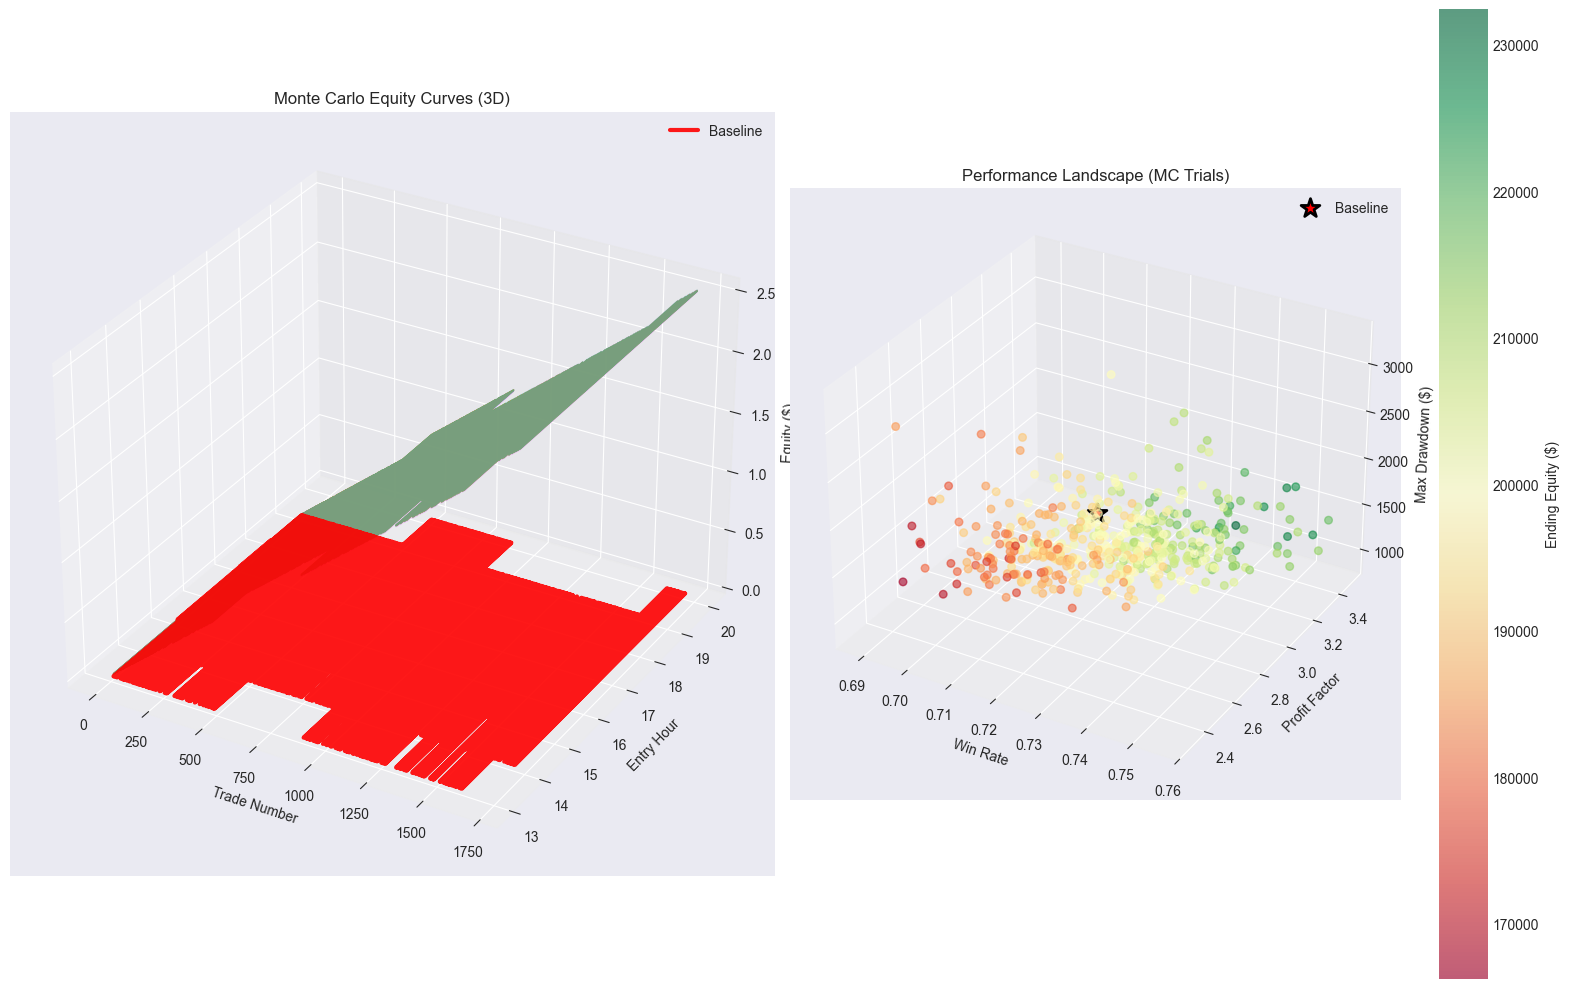

In [ ]:
# 3D Monte Carlo Equity Curve Comparison
fig = plt.figure(figsize=(16, 10))

# Plot multiple Monte Carlo equity curves in 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Sample 20 random equity curves from Monte Carlo results
if 'mc_result' in locals() and len(mc_result['raw_results']['ending_equities']) > 0:
    n_curves = min(20, len(mc_result['raw_results']['ending_equities']))
    indices = np.random.choice(len(mc_result['raw_results']['ending_equities']), n_curves, replace=False)
    
    # Simulate equity curves (we'll approximate using the P&L distribution)
    for idx in indices[:10]:  # Show first 10 for clarity
        # Generate a random sequence of trades
        sampled_pnl = np.random.choice(mc_result['raw_results']['net_pnls'], size=len(trades_df), replace=True)
        equity_curve = initial_equity + np.cumsum(sampled_pnl)
        
        # Plot in 3D with trade number and hour (approximate)
        trade_numbers = range(len(equity_curve))
        # Use entry hours if available, otherwise approximate
        if 'entry_hour' in trades_df.columns and len(trades_df) == len(equity_curve):
            hours = trades_df['entry_hour'].values
        else:
            hours = np.linspace(8, 15, len(equity_curve))
        
        ax1.plot(trade_numbers, hours, equity_curve, alpha=0.3, linewidth=1)
    
    # Plot baseline equity curve
    baseline_equity = initial_equity + trades_df['cumulative_pnl'].values
    if 'entry_hour' in trades_df.columns:
        baseline_hours = trades_df['entry_hour'].values
    else:
        baseline_hours = np.linspace(8, 15, len(baseline_equity))
    ax1.plot(range(len(baseline_equity)), baseline_hours, baseline_equity, 
             'r-', linewidth=3, label='Baseline', alpha=0.9)
    
    ax1.set_xlabel('Trade Number')
    ax1.set_ylabel('Entry Hour')
    ax1.set_zlabel('Equity ($)')
    ax1.set_title('Monte Carlo Equity Curves (3D)')
    ax1.legend()

# 3D Performance Landscape: Win Rate vs Profit Factor vs Max Drawdown
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Extract Monte Carlo results
if 'mc_result' in locals():
    wr_data = mc_result['raw_results']['win_rates']
    pf_data = mc_result['raw_results']['profit_factors']
    dd_data = mc_result['raw_results']['max_drawdowns']
    
    # Filter out infinite profit factors
    valid_mask = np.array([pf < 100 for pf in pf_data])
    wr_filtered = np.array(wr_data)[valid_mask]
    pf_filtered = np.array(pf_data)[valid_mask]
    dd_filtered = np.array(dd_data)[valid_mask]
    
    # Color by ending equity (better = greener)
    eq_filtered = np.array(mc_result['raw_results']['ending_equities'])[valid_mask]
    colors_3d = eq_filtered
    
    scatter = ax2.scatter(wr_filtered, pf_filtered, dd_filtered, 
                          c=colors_3d, cmap='RdYlGn', alpha=0.6, s=30)
    
    # Mark baseline
    baseline_wr = backtest['summary']['win_rate']
    baseline_pf = backtest['summary']['profit_factor'] if backtest['summary']['profit_factor'] != float('inf') else 10
    baseline_dd = backtest['summary']['max_drawdown']
    ax2.scatter([baseline_wr], [baseline_pf], [baseline_dd], 
                c='red', s=200, marker='*', edgecolors='black', linewidths=2, label='Baseline')
    
    ax2.set_xlabel('Win Rate')
    ax2.set_ylabel('Profit Factor')
    ax2.set_zlabel('Max Drawdown ($)')
    ax2.set_title('Performance Landscape (MC Trials)')
    fig.colorbar(scatter, ax=ax2, label='Ending Equity ($)')
    ax2.legend()

plt.tight_layout()
plt.show()


3D Parameter Space Analysis Template
To use this effectively, run backtests with different parameter combinations
and collect the results. Then plot them in 3D space.

Example dimensions to explore:
  - Stop Loss Ticks vs Target Multiplier vs Win Rate
  - Min Probability Threshold vs Contracts vs Profit Factor
  - Max Hold Bars vs Stop Ticks vs Ending Equity


/var/folders/2n/wfddn5mn0d18dcql5s1h9lhm0000gn/T/ipykernel_37129/1874059633.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


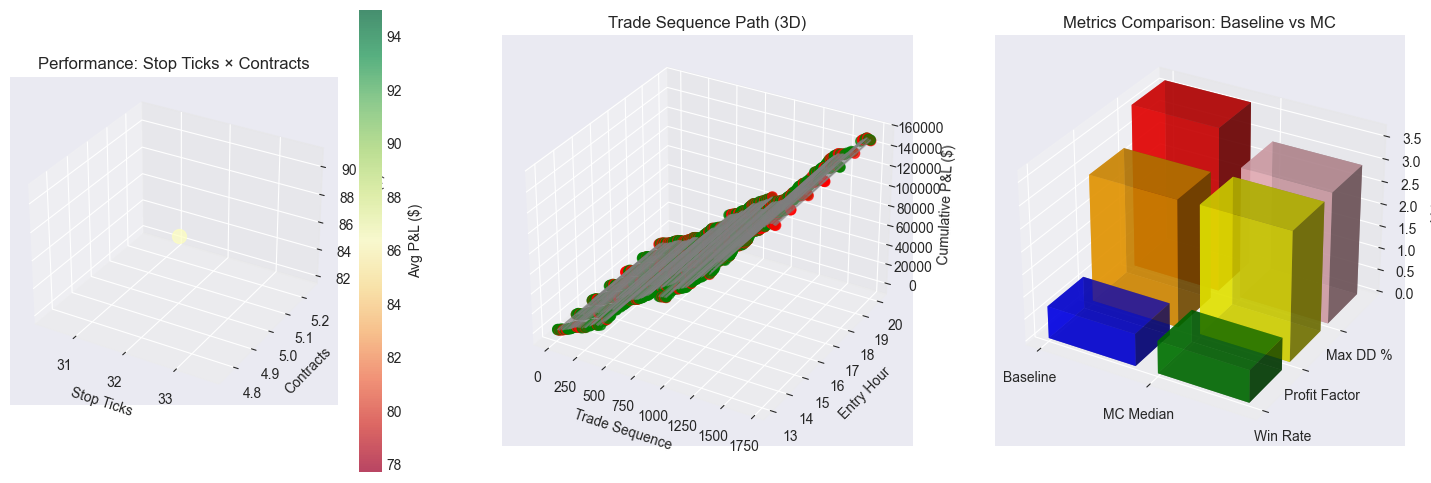

In [ ]:
# 3D Parameter Sensitivity Analysis (if you want to explore different configs)
# This cell shows how you could visualize performance across different parameter combinations

fig = plt.figure(figsize=(18, 6))

# Example: If you were to test different stop_loss_ticks and target_multiplier combinations
# This is a template - adjust based on what parameters you want to analyze

ax = fig.add_subplot(1, 3, 1, projection='3d')

# Create example parameter grid (you would run multiple backtests with different params)
# For now, we'll use the current backtest and show the structure

print("3D Parameter Space Analysis Template")
print("="*60)
print("To use this effectively, run backtests with different parameter combinations")
print("and collect the results. Then plot them in 3D space.")
print("\nExample dimensions to explore:")
print("  - Stop Loss Ticks vs Target Multiplier vs Win Rate")
print("  - Min Probability Threshold vs Contracts vs Profit Factor")
print("  - Max Hold Bars vs Stop Ticks vs Ending Equity")

# Create a conceptual visualization using the current data
if len(trades_df) > 0:
    # Use actual data to show structure
    stop_ticks_unique = sorted(trades_df['stop_ticks'].unique())
    contracts_unique = sorted(trades_df['contracts'].unique())
    
    # Calculate average metrics for each combination
    z_data = []
    x_data = []
    y_data = []
    
    for stop_ticks in stop_ticks_unique[:5]:  # Limit for clarity
        for contracts in contracts_unique:
            mask = (trades_df['stop_ticks'] == stop_ticks) & (trades_df['contracts'] == contracts)
            if mask.sum() > 0:
                avg_pnl = trades_df[mask]['pnl'].mean()
                x_data.append(stop_ticks)
                y_data.append(contracts)
                z_data.append(avg_pnl)
    
    if x_data:
        scatter = ax.scatter(x_data, y_data, z_data, c=z_data, cmap='RdYlGn', s=100, alpha=0.7)
        ax.set_xlabel('Stop Ticks')
        ax.set_ylabel('Contracts')
        ax.set_zlabel('Avg P&L ($)')
        ax.set_title('Performance: Stop Ticks × Contracts')
        fig.colorbar(scatter, ax=ax, label='Avg P&L ($)')

# 3D Trade Sequence Analysis
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

# Plot trade sequence showing win/loss pattern
trades_df['trade_sequence'] = range(len(trades_df))
trades_df['cumulative_pnl_3d'] = trades_df['pnl'].cumsum()

# Color by win/loss
colors_seq = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
ax2.scatter(trades_df['trade_sequence'], 
            trades_df['entry_hour'], 
            trades_df['cumulative_pnl_3d'],
            c=colors_seq, alpha=0.7, s=50)

# Draw lines connecting consecutive trades
for i in range(len(trades_df) - 1):
    ax2.plot([trades_df.iloc[i]['trade_sequence'], trades_df.iloc[i+1]['trade_sequence']],
             [trades_df.iloc[i]['entry_hour'], trades_df.iloc[i+1]['entry_hour']],
             [trades_df.iloc[i]['cumulative_pnl_3d'], trades_df.iloc[i+1]['cumulative_pnl_3d']],
             color='gray', alpha=0.3, linewidth=1)

ax2.set_xlabel('Trade Sequence')
ax2.set_ylabel('Entry Hour')
ax2.set_zlabel('Cumulative P&L ($)')
ax2.set_title('Trade Sequence Path (3D)')

# 3D Performance Metrics Comparison
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Compare different performance metrics
metrics_data = {
    'Win Rate': backtest['summary']['win_rate'],
    'Profit Factor': min(backtest['summary']['profit_factor'], 10) if backtest['summary']['profit_factor'] != float('inf') else 10,
    'Ending Equity (norm)': (backtest['summary']['ending_equity'] - initial_equity) / initial_equity * 100,
    'Max DD (norm)': backtest['summary']['max_drawdown'] / initial_equity * 100,
}

# Create a 3D bar showing key metrics
if 'mc_result' in locals():
    # Show baseline vs MC median
    x_labels = ['Baseline', 'MC Median']
    metrics_3d = {
        'Win Rate': [backtest['summary']['win_rate'], mc_result['summary']['win_rate']['p50']],
        'Profit Factor': [
            min(backtest['summary']['profit_factor'], 10) if backtest['summary']['profit_factor'] != float('inf') else 10,
            mc_result['summary']['profit_factor']['p50']
        ],
        'Max DD %': [
            backtest['summary']['max_drawdown'] / initial_equity * 100,
            mc_result['summary']['max_drawdown']['p50'] / initial_equity * 100
        ]
    }
    
    xpos = [0, 1]
    ypos = [0, 1, 2]
    zpos = [0, 0, 0, 0, 0, 0]
    dx = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
    dy = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
    dz = [metrics_3d['Win Rate'][0], metrics_3d['Win Rate'][1],
          metrics_3d['Profit Factor'][0], metrics_3d['Profit Factor'][1],
          metrics_3d['Max DD %'][0], metrics_3d['Max DD %'][1]]
    
    colors_metrics = ['blue', 'green', 'orange', 'yellow', 'red', 'pink']
    ax3.bar3d([0, 1, 0, 1, 0, 1], [0, 0, 1, 1, 2, 2], zpos, dx, dy, dz, 
              color=colors_metrics, alpha=0.7)
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Baseline', 'MC Median'])
    ax3.set_yticks([0, 1, 2])
    ax3.set_yticklabels(['Win Rate', 'Profit Factor', 'Max DD %'])
    ax3.set_zlabel('Value')
    ax3.set_title('Metrics Comparison: Baseline vs MC')

plt.tight_layout()
plt.show()


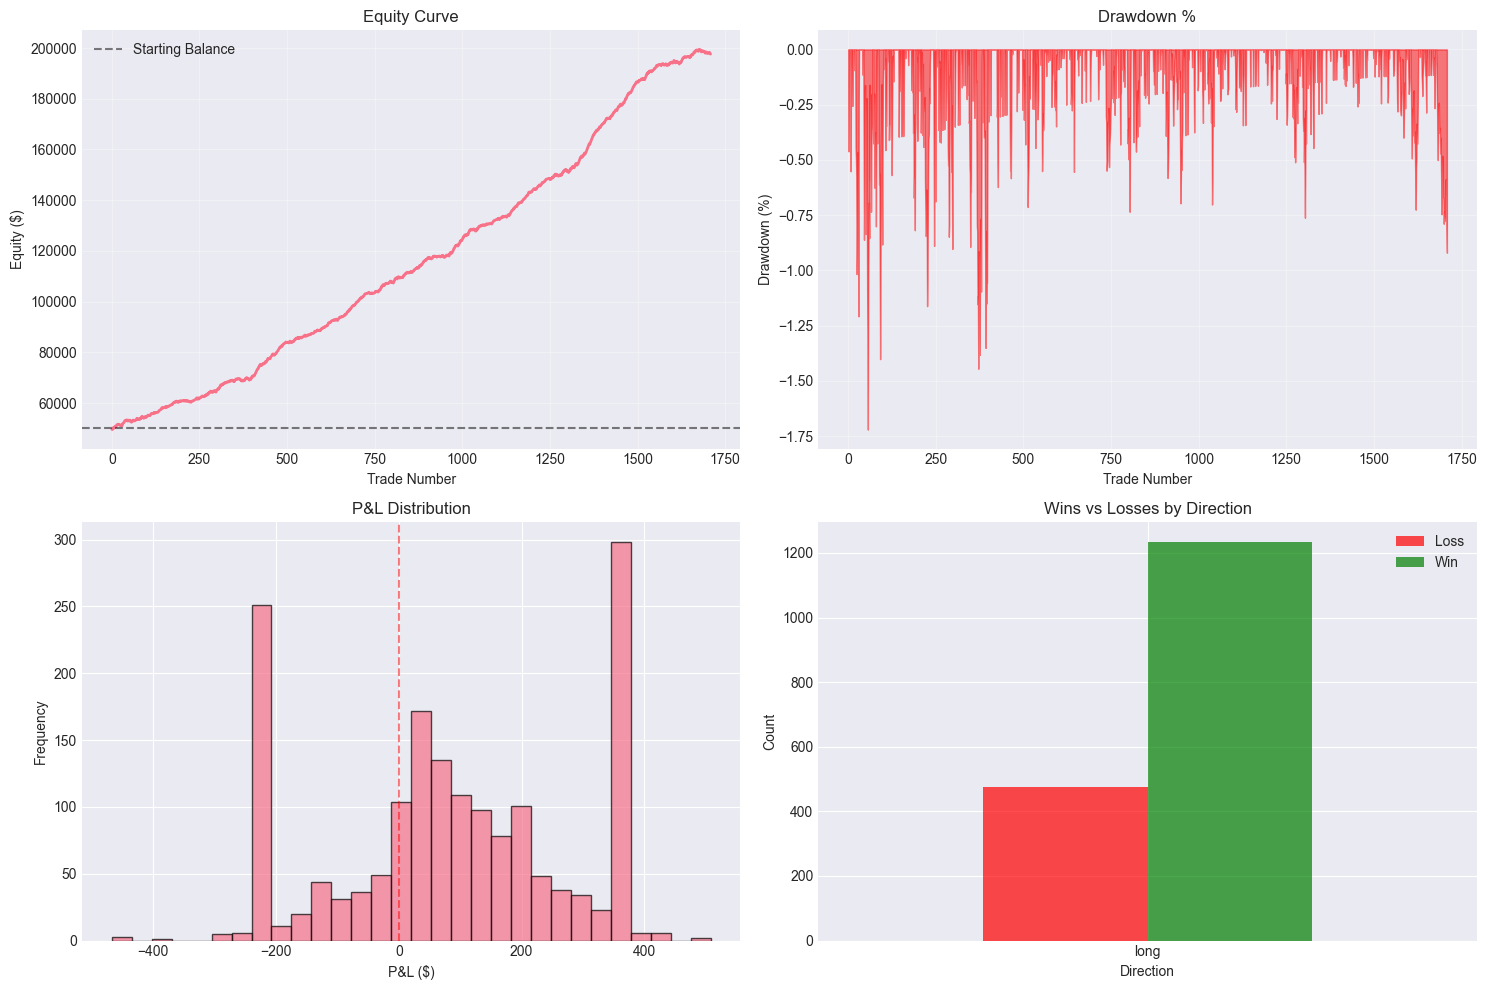


Trade Statistics:
Total trades: 1709
Winning trades: 1233
Losing trades: 476
Average win: $184.25
Average loss: $-167.17
Largest win: $507.75
Largest loss: $-467.25


In [ ]:
# Visualize backtest results
trades_df = pd.DataFrame(backtest["trades"])

if len(trades_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Equity curve
    trades_df["cumulative_pnl"] = trades_df["pnl"].cumsum()
    starting_balance = backtest["summary"]["starting_balance"]
    equity_curve = starting_balance + trades_df["cumulative_pnl"]
    
    axes[0, 0].plot(range(len(equity_curve)), equity_curve, linewidth=2)
    axes[0, 0].axhline(y=starting_balance, color='black', linestyle='--', alpha=0.5, label='Starting Balance')
    axes[0, 0].set_title('Equity Curve')
    axes[0, 0].set_xlabel('Trade Number')
    axes[0, 0].set_ylabel('Equity ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Drawdown
    peaks = equity_curve.expanding().max()
    drawdown = (equity_curve - peaks) / peaks * 100
    axes[0, 1].fill_between(range(len(drawdown)), drawdown, 0, alpha=0.5, color='red')
    axes[0, 1].set_title('Drawdown %')
    axes[0, 1].set_xlabel('Trade Number')
    axes[0, 1].set_ylabel('Drawdown (%)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # P&L distribution
    axes[1, 0].hist(trades_df["pnl"], bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('P&L Distribution')
    axes[1, 0].set_xlabel('P&L ($)')
    axes[1, 0].set_ylabel('Frequency')
    
    # Win/Loss by direction
    win_loss = trades_df.groupby(["direction", (trades_df["pnl"] > 0)]).size().unstack(fill_value=0)
    win_loss.plot(kind='bar', ax=axes[1, 1], color=['red', 'green'], alpha=0.7)
    axes[1, 1].set_title('Wins vs Losses by Direction')
    axes[1, 1].set_xlabel('Direction')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend(['Loss', 'Win'])
    axes[1, 1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Trade statistics
    print("\nTrade Statistics:")
    print(f"Total trades: {len(trades_df)}")
    print(f"Winning trades: {(trades_df['pnl'] > 0).sum()}")
    print(f"Losing trades: {(trades_df['pnl'] < 0).sum()}")
    print(f"Average win: ${trades_df[trades_df['pnl'] > 0]['pnl'].mean():.2f}")
    print(f"Average loss: ${trades_df[trades_df['pnl'] < 0]['pnl'].mean():.2f}")
    print(f"Largest win: ${trades_df['pnl'].max():.2f}")
    print(f"Largest loss: ${trades_df['pnl'].min():.2f}")


## 7. Overfitting Detection & Model Diagnostics

Analyze model performance across train/validation/test splits to detect overfitting and diagnose model issues.


In [ ]:
# Diagnostics: NN artifact + backtest sanity check
print('='*60)
print('DIAGNOSTICS: NN ARTIFACT + BACKTEST')
print('='*60)

if 'bundle' not in locals():
    raise RuntimeError('Run the training/loading cell first.')

metrics = bundle.config.get('metrics', {})
if metrics:
    print('Model metrics (AUC / log loss):')
    for side in ['long', 'short']:
        m = metrics.get(side, {})
        if not m:
            continue
        print(
            f"  {side.upper()} AUC (val/test)={m.get('val_auc', 0):.3f}/{m.get('test_auc', 0):.3f} "
            f"logloss (val/test)={m.get('val_log_loss', 0):.3f}/{m.get('test_log_loss', 0):.3f}"
        )
else:
    print('No metrics found in artifact config.')

if 'backtest' in locals():
    print('\nBacktest summary:')
    print(pyjson.dumps(backtest.get('summary', {}), indent=2))
    print('\nDaily stats:')
    print(pyjson.dumps(backtest.get('daily_stats', {}), indent=2))


DIAGNOSTICS: TRAIN/VAL/TEST vs TRADE-IDENTICAL BACKTEST
1) Classification metrics (train/val/test) on the label dataset:
LONG model
  training   acc=0.796 auc=0.877 label_trades@thr=556 wr=0.987 pf=156.86
  validation acc=0.565 auc=0.530 label_trades@thr=61 wr=0.213 pf=0.54
  test       acc=0.539 auc=0.531 label_trades@thr=28 wr=0.429 pf=1.50
SHORT model
  training   acc=0.797 auc=0.889 label_trades@thr=347 wr=0.965 pf=55.83
  validation acc=0.526 auc=0.508 label_trades@thr=61 wr=0.689 pf=4.42
  test       acc=0.507 auc=0.505 label_trades@thr=26 wr=0.154 pf=0.36
2) Trade-identical backtest summaries by bar-split (this is the KPI):


<IPython.core.display.JSON object>

3) Tuned policy (selected on validation):


<IPython.core.display.JSON object>

NOTE: Policy stood down (0 trades) on test -> no robust validation edge under current constraints.


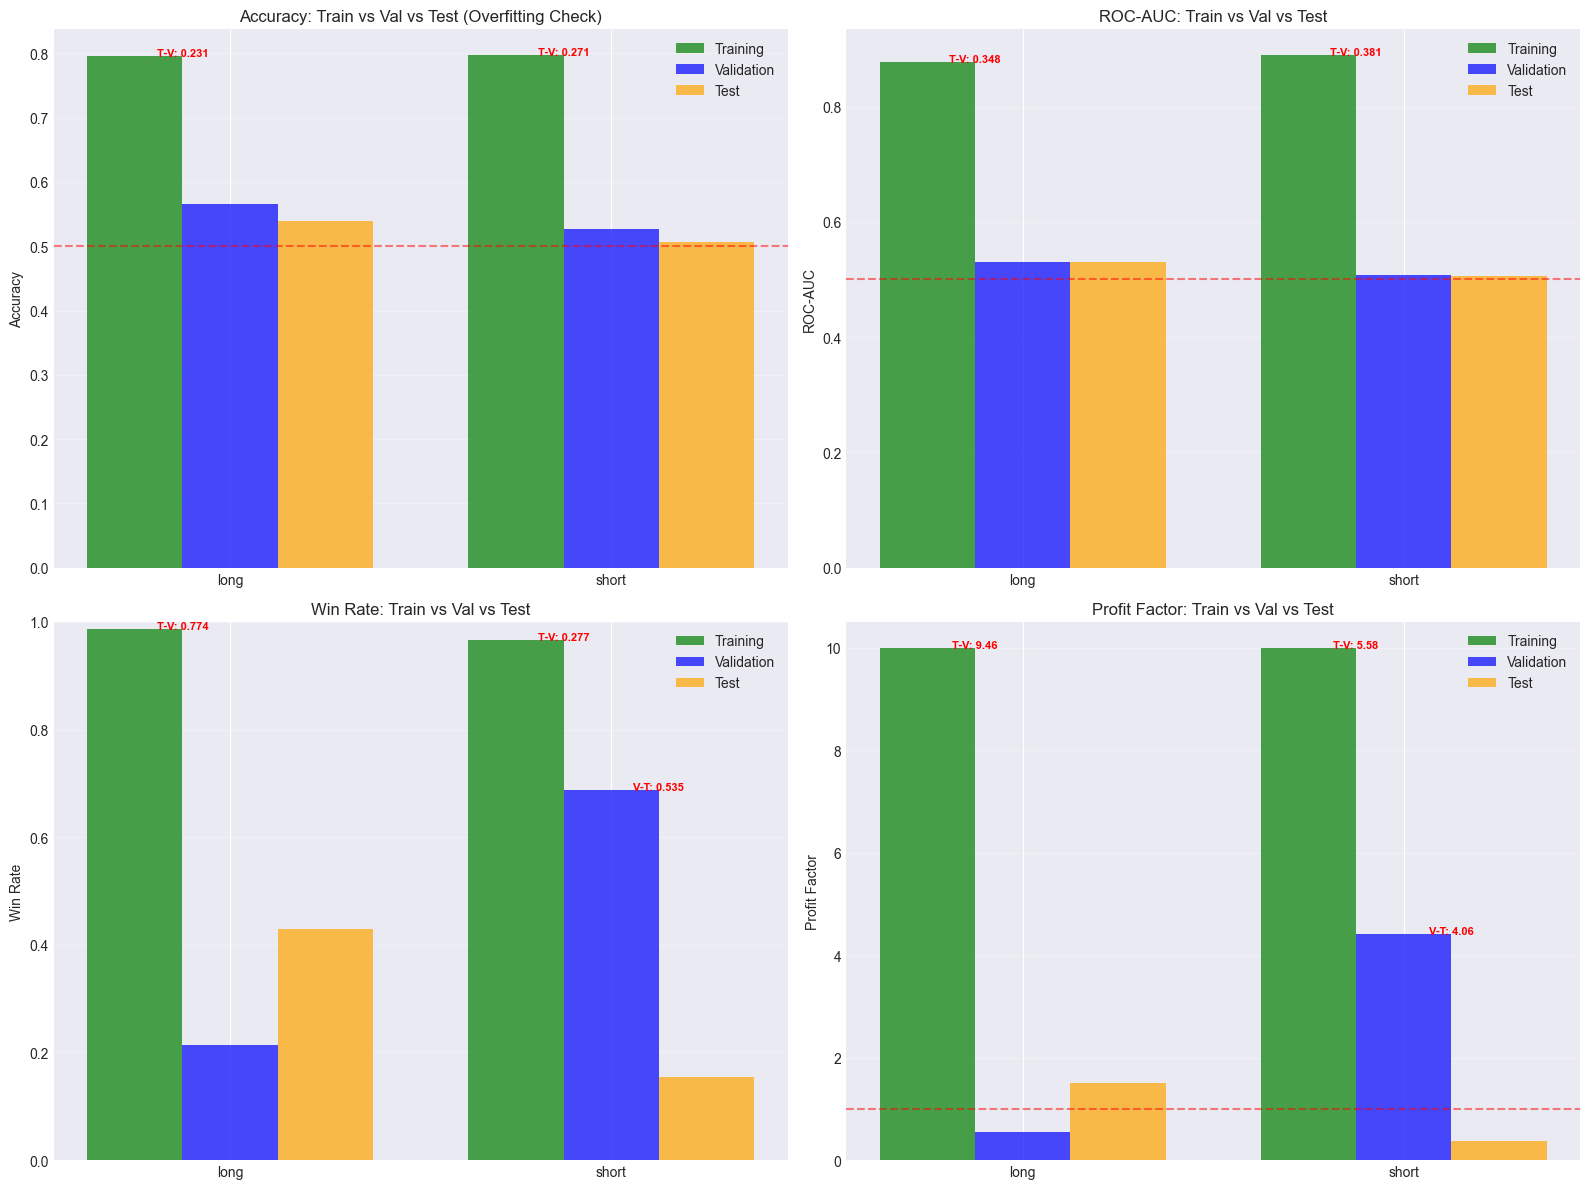


OVERFITTING ASSESSMENT

LONG Model:

SHORT Model:

⚠️  OVERFITTING DETECTED:
   - long: Train-Val accuracy gap 0.231
   - short: Train-Val accuracy gap 0.271

   Recommendations:
   • Reduce model complexity (lower max_depth, increase min_samples_leaf)
   • Add more regularization
   • Increase training data
   • Use feature selection to reduce dimensionality
   • Try simpler models (fewer trees, shallower trees)


In [ ]:
# Visualize model AUCs (if available)
metrics = bundle.config.get('metrics', {}) if 'bundle' in locals() else {}
if metrics:
    fig, ax = plt.subplots(figsize=(8, 4))
    sides = ['long', 'short']
    val = [metrics.get(s, {}).get('val_auc', 0) for s in sides]
    test = [metrics.get(s, {}).get('test_auc', 0) for s in sides]
    x = np.arange(len(sides))
    width = 0.35
    ax.bar(x - width/2, val, width, label='Val AUC', color='steelblue')
    ax.bar(x + width/2, test, width, label='Test AUC', color='orange')
    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in sides])
    ax.set_ylim(0, 1)
    ax.set_title('Validation vs Test AUC')
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print('No metrics to plot; run the training/loading cell first.')



FEATURE IMPORTANCE ANALYSIS


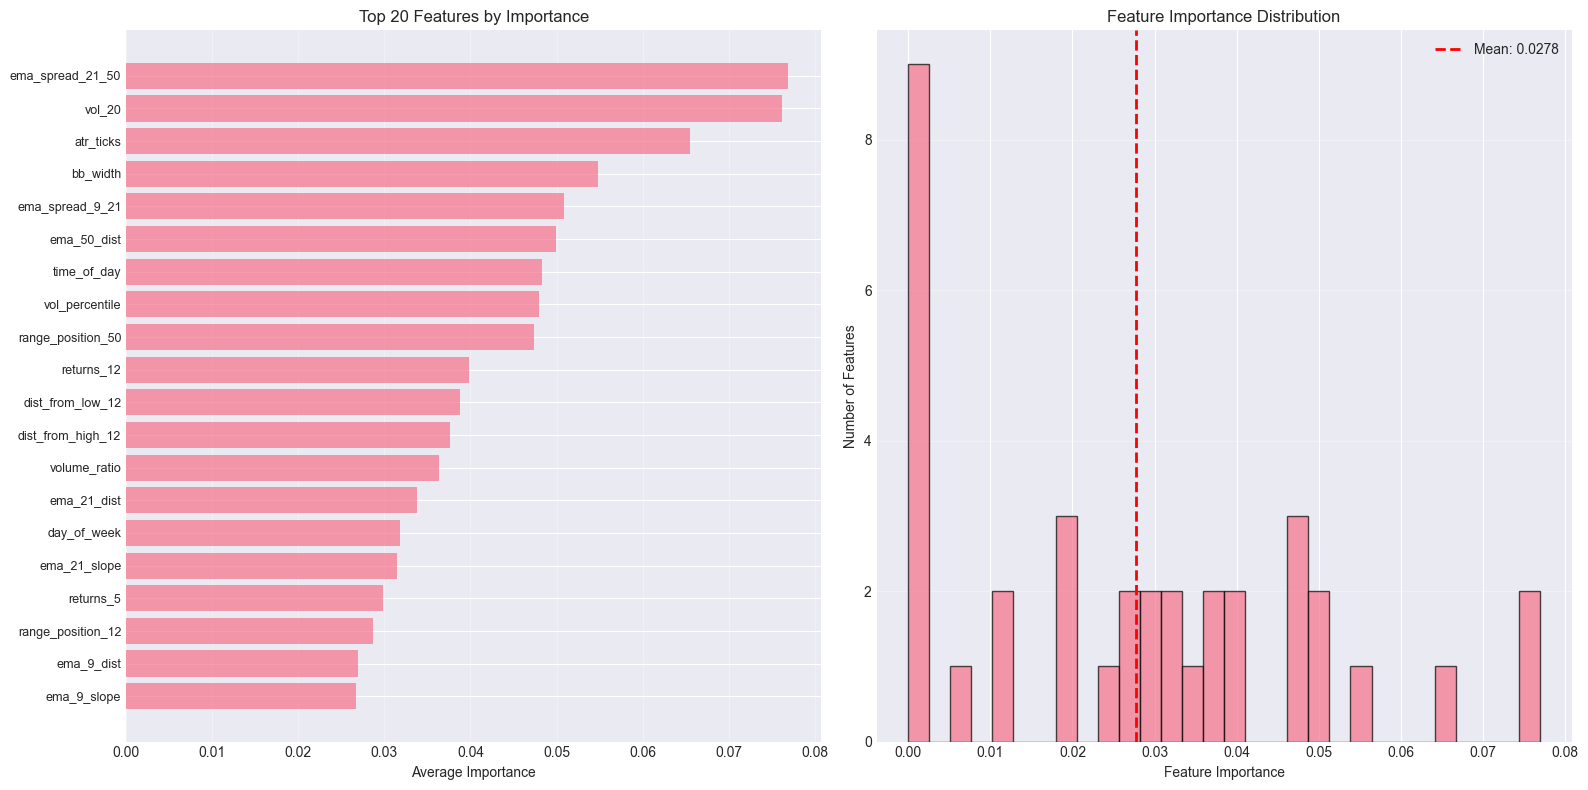


Feature Importance Analysis:
   Total features: 36
   Mean importance: 0.0278
   Std dev: 0.0223
   Top 10 features account for: 55.8% of importance

   Top 10 Most Important Features:
      ema_spread_21_50              : 0.0769
      vol_20                        : 0.0762
      atr_ticks                     : 0.0655
      bb_width                      : 0.0548
      ema_spread_9_21               : 0.0508
      ema_50_dist                   : 0.0499
      time_of_day                   : 0.0483
      vol_percentile                : 0.0479
      range_position_50             : 0.0474
      returns_12                    : 0.0398


In [ ]:
# Feature importance (not available for tiny MLP)
print("Feature importance is not available for the tiny MLP model.")
print("Use permutation importance or SHAP externally if needed.")


## How to Fix Overfitting (if detected)

If overfitting is detected, here are actionable steps:


In [ ]:
# Next experiments (prioritized)
print('='*60)
print('NEXT EXPERIMENTS (PRIORITIZED)')
print('='*60)

if 'nn_cfg' in locals():
    print(
        f"Current notebook config: horizon={nn_cfg.get('horizon_bars')}, "
        f"threshold_ticks={nn_cfg.get('threshold_ticks')}, "
        f"score_quantile={nn_cfg.get('score_quantile')}, "
        f"max_trades/day={nn_cfg.get('max_trades_per_day')}, "
        f"min_spacing={nn_cfg.get('min_bars_between_trades')}"
    )

print("""1) Re-run on multiple windows (walk-forward folds)
   - The current window is only one sample of regime behavior.
   - Add 3-5 rolling folds and require consistent validation profitability before going live.

2) Tune horizon/threshold to stabilize signal density
   - Adjust horizon_bars/threshold_ticks and re-train.
   - Validate with the ML-only top-N selector.

3) Score distribution audit
   - Monitor score percentiles and trades/day.
   - If trades/day < 1, lower score_quantile or target_trades_per_day.

4) Stress test on 24H vs RTH
   - Flip session_mode to 24H and recalibrate score_quantile via target_trades_per_day.
""")


NEXT EXPERIMENTS (PRIORITIZED)
Current notebook config: label_mode=per_bar, stop=32, target_mult=2.0, max_hold=12
1) Re-run on multiple windows (walk-forward folds)
   - The current train/val/test split is only one sample of regime behavior.
   - Add 3-5 rolling folds and require consistent validation profitability before going live.

2) Re-check stop/target/hold under REAL execution
   - Use `analysis/optimize_stops.py` to sanity-check whether the label EV is positive.
   - Then re-train with those parameters and validate via trade-identical backtest.

3) Threshold calibration
   - Treat the model probability as a score, not a calibrated probability.
   - Optimize threshold on validation for `net_pnl - λ*max_drawdown` with a minimum trade count.

4) Gating and regime filters
   - Time filters (avoid lunch / low-liquidity), ATR band, and trend alignment are already supported.
   - Expand the candidate gates carefully and require stability (not one lucky segment).

5) Model alternatives